In [3]:
!pip install fastf1
import fastf1
import os
import pandas as pd
import numpy as np

cache_path = r'C:\Users\elesn\Downloads\Szakdoga\cache'
os.makedirs(cache_path, exist_ok=True)

fastf1.Cache.enable_cache(cache_path)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
years = range(2018, 2024)
all_data = []

for year in years:
    session = fastf1.get_session(year, 'Bahrain', 'R')
    session.load()

    laps = session.laps.copy()
    weather = session.weather_data.copy()

    laps = pd.merge_asof(laps.sort_values('Time'),weather.sort_values('Time'),on='Time',direction='backward') #idő szerint illesztjük össze a két adattáblát
    #minden körhöz tartozni fog a hozzá időben legközelebb álló időjárási adat

    laps['Year'] = year

    all_data.append(laps)

#df = pd.concat(all_data)
#df = df[df['Driver'] == 'VER'].copy() #itt konkrétan egy pilótát választok ki, a későbbiekben ezt fogom megvizsgálni több versenyzőre
#print(df.columns)
#df.head()
df = pd.concat(all_data, ignore_index=True)

# csak a 2023-as szezon kiértékelésre
#df_2023 = df_all[df_all['Year'] == 2023].copy()

print(df.columns)
df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
core        WARNING 	Car telemetry data is unavailable!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
core        WARNING 	Car position data is unavailable!
core        WARNING 	Failed to determine `Session.t0_date`!
logger      WARNING 	Failed to load telemetry data!
req    

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity', 'Pressure',
       'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'Year'],
      dtype='object')


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FastF1Generated,IsAccurate,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,Year
0,0 days 00:09:12.347000,VET,5,0 days 00:01:35.238000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:40.676000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
1,0 days 00:09:13.814000,BOT,77,0 days 00:01:36.705000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.160000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
2,0 days 00:09:14.770000,RAI,7,0 days 00:01:37.661000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.537000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
3,0 days 00:09:15.824000,RIC,3,0 days 00:01:38.684000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.585000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
4,0 days 00:09:17.432000,GAS,10,0 days 00:01:40.323000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:42.641000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018


In [5]:
#adattisztítás:
df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds() #másodperces alakra átírom a köridőket
df_clean = df[~df['TrackStatus'].str.contains('2|3|4|5|6|7', na=False)].copy() #csak a zöld körök maradnak meg
df_clean = df_clean[df_clean['PitOutTime'].isna()] # a boxba kiálló körök torzítják a modellt
df_clean = df_clean[df_clean['PitInTime'].isna()]
#df = df[df['LapTimeSeconds'] < df['LapTimeSeconds'].quantile(0.99)] #outlier körök:elhibázott körök, forgalom miatti lasabb körök?
#df = df[df['TyreLife'] > 1] első kör még nem reprezentatív?
df_clean = df_clean.dropna(subset=['TyreLife','TrackTemp','LapTimeSeconds']) #hiányzó értékek kiszűrése, itt valami mérési hibára utalhatnak
print("Szűrés után:", len(df_clean))

Szűrés után: 4850


In [6]:
#változók kiválasztása a köridő/base modellhez:
features = ['TyreLife','LapNumber', 'Compound', 'Stint', 'TrackTemp','Driver','Team'] #konstruktőr és versenyző specifikus modell(nem kell a driver oszlop, mert egy konkrét versenyzőre vizsgáljuk, majd itt változtatjuk az értéket)
#kérdés maradhat-e a tyrelife és lapnumber, mert ezek erősen korrelálhatnak egymással
target = 'LapTimeSeconds'

train_df = df_clean[df_clean['Year'] <= 2021]
test_df  = df_clean[df_clean['Year'] > 2021]
df_model_train = train_df[features + [target]].copy()
df_model_test  = test_df[features + [target]].copy()
df_model_train = pd.get_dummies(df_model_train, columns=['Compound','Team','Driver'])
df_model_test  = pd.get_dummies(df_model_test, columns=['Compound','Team','Driver'])
df_model_train, df_model_test = df_model_train.align(df_model_test, join='outer', axis=1, fill_value=0)

X_train = df_model_train.drop(columns=[target])
y_train = df_model_train[target]

X_test = df_model_test.drop(columns=[target])
y_test = df_model_test[target]

print(type(X_train))
print(type(X_test))

print(X_train.shape)
print(X_test.shape)

<class 'fastf1.core.Laps'>
<class 'fastf1.core.Laps'>
(3083, 57)
(1767, 57)


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models_base = {
    "DecisionTree": DecisionTreeRegressor(max_depth=8),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05)
} 

from sklearn.metrics import mean_absolute_error

results_base = {}

for name, model in models_base.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)

    results_base[name] = mae
    print(f"{name} MAE:", mae)

best_base_name = min(results_base, key=results_base.get) #legjobb modell a kiértékelések alapján
base_model = models_base[best_base_name]
base_model.fit(X_train, y_train)
FEATURE_COLUMNS = base_model.feature_names_in_

print("Best base model:", best_base_name)


DecisionTree MAE: 2.1193302467974355
RandomForest MAE: 2.031440469722697
GradientBoosting MAE: 2.049120704112968
Best base model: RandomForest


In [35]:
#neurális háló:
# FEATURE LISTÁK

BASE_FEATURES = base_model.feature_names_in_

MLP_FEATURES = BASE_FEATURES

# RNN-hez időfüggő feature-ök
RNN_FEATURES = [
    'LapNumber',
    'TyreLife',
    'TrackTemp',
    'Stint',
    'Compound'
]

SEQ_LEN = 10

#modell felépítése:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def build_mlp():

    model = Sequential()

    model.add(Input(shape=(len(MLP_FEATURES),)))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

#sequence generálás:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler #skálázáshoz

def build_sequences(df):

    sequences = []
    targets = []

    for driver, d in df.groupby("Driver"):

        d = d.sort_values("LapNumber").copy()

        d = pd.get_dummies(
            d,
            columns=["Compound"]
        )

    # feature oszlopok
    feature_cols = [
        'LapNumber',
        'TyreLife',
        'TrackTemp',
        'Stint'
    ]

    # compound dummy oszlopok
    compound_cols = [
        c for c in d.columns
        if c.startswith('Compound_')
    ]

    feature_cols += compound_cols

    # csak szükséges oszlopok
    d = d[feature_cols + ['LapTimeSeconds']].dropna()

    #  MINDENT float típusra
    d = d.astype(float)

    data = d.values

    if len(data) <= SEQ_LEN:
        return np.array([]), np.array([])

    for i in range(len(data) - SEQ_LEN):

        sequences.append(
            data[i:i+SEQ_LEN, :-1]
        )

        targets.append(
            data[i+SEQ_LEN, -1]
        )

    return (
        np.array(sequences, dtype=np.float32),
        np.array(targets, dtype=np.float32)
    )
    

In [36]:
#RNN:
from tensorflow.keras.layers import SimpleRNN

def build_rnn(input_shape):

    model = Sequential()

    model.add(
        Input(shape=input_shape)
    )

    model.add(
        SimpleRNN(
            16,
            return_sequences=False
        )
    )

    model.add(Dense(32, activation='relu'))

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

#adatelőkészítés:

from sklearn.model_selection import train_test_split

X_rnn, y_rnn = build_sequences(df_clean)

scaler = StandardScaler()

X_flat = X_rnn.reshape(-1, X_rnn.shape[-1])

X_flat = scaler.fit_transform(X_flat)

X_rnn = X_flat.reshape(
    X_rnn.shape[0],
    X_rnn.shape[1],
    X_rnn.shape[2]
)

print(X_rnn.shape)
print(y_rnn.shape)

X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_rnn,
    y_rnn,
    test_size=0.2,
    shuffle=False
)

#tanítás:

rnn_model = build_rnn(
    (X_train_rnn.shape[1], X_train_rnn.shape[2])
)

history = rnn_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

#predikció és kiértékelés:

from sklearn.metrics import mean_absolute_error

y_pred = rnn_model.predict(X_test_rnn)

y_pred = y_pred.flatten()

mae = mean_absolute_error(
    y_test_rnn,
    y_pred
)

print("RNN MAE:", mae)

(81, 10, 7)
(81,)
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - loss: 9833.7754 - mae: 99.1590 - val_loss: 9394.0928 - val_mae: 96.9124
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 9827.8525 - mae: 99.1296 - val_loss: 9388.7344 - val_mae: 96.8847
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 9800.7148 - mae: 98.9926 - val_loss: 9383.8838 - val_mae: 96.8596
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 9781.5479 - mae: 98.8947 - val_loss: 9378.6240 - val_mae: 96.8324
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 9775.8584 - mae: 98.8667 - val_loss: 9372.9463 - val_mae: 96.8030
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 9765.0898 - mae: 98.8116 - val_loss: 9366.9941 - val_mae: 96.7721
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 9728.0996 - mae: 98.6253 - val_loss: 9360.9990 - val_mae: 96.7411
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 9717.6396 - mae: 98.5712 - val_loss: 9355.0410 - val_mae: 

In [8]:
X_test = X_test.astype(float) #shap stabilabban működik float típusú adatokkal 
import shap 
explainer = shap.TreeExplainer(base_model) 
shap_values = explainer.shap_values(X_test) #magyarázat: minden elem a következőléppen néz ki: shap_values[i, j], ami azt jelenti, hogy a j-edik feauture mennyivel változtatta meg az i-edik kör predikcióját 

degradation_cache = {} #gyorsítani fogja a dp részt

MAX_LAPS = 80
MAX_TYRE_LIFE = 40

for lap in range(1, MAX_LAPS + 1):

    for tyre_life in range(1, MAX_TYRE_LIFE + 1):

        X = pd.DataFrame(
            0.0,
            index=[0],
            columns=base_model.feature_names_in_
        )

        # numerikus feature-ök
        if 'LapNumber' in X.columns:
            X.at[0, 'LapNumber'] = lap

        if 'TyreLife' in X.columns:
            X.at[0, 'TyreLife'] = tyre_life

        if 'TrackTemp' in X.columns:
            X.at[0, 'TrackTemp'] = 30

        if 'Stint' in X.columns:
            X.at[0, 'Stint'] = 1

        # SHAP számítás
        shap_vals = explainer.shap_values(X)

        idx = X.columns.get_loc('TyreLife')

        degradation_value = max(
            0,
            shap_vals[0, idx]
        )

        degradation_cache[
            (lap, tyre_life)
        ] = degradation_value

def get_degradation(lap, tyre_life): 
    return degradation_cache.get(
        (lap, tyre_life),
        0
    ) 
    #return shap_vals[0, idx] 
tyrelife_col = 'TyreLife' 
tyrelife_idx = list(X_test.columns).index('TyreLife') 
deg_proxy = shap_values[:, tyrelife_idx]

c:\Users\elesn\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
print(X_test.shape)
print(base_model.feature_names_in_.shape) #shap működéséhez ellenőrzés

(91, 8)
(8,)


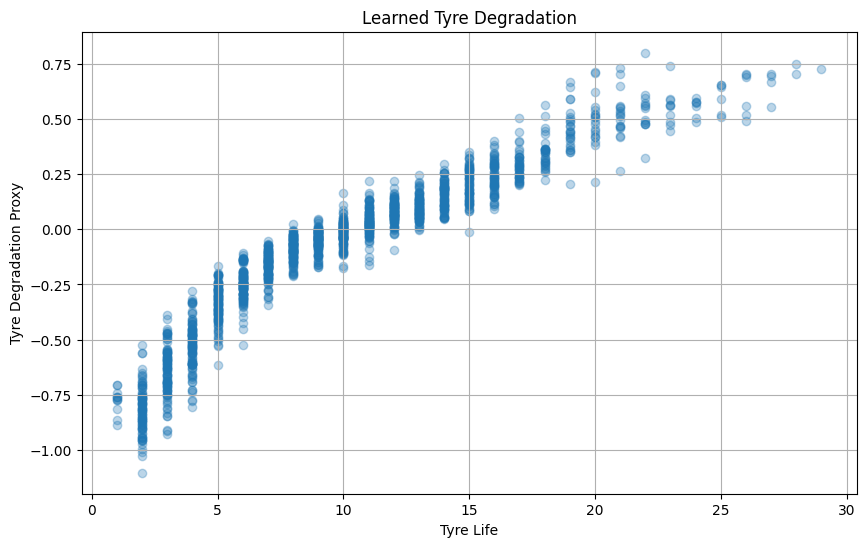

In [9]:
# tyrelife szerint ábrázolás:
import matplotlib.pyplot as plt

plot_df = X_test.copy()

plot_df['DegProxy'] = deg_proxy

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df['TyreLife'],
    plot_df['DegProxy'],
    alpha=0.3
)

plt.xlabel("Tyre Life")
plt.ylabel("Tyre Degradation Proxy")

plt.title("Learned Tyre Degradation")

plt.grid()
plt.show()

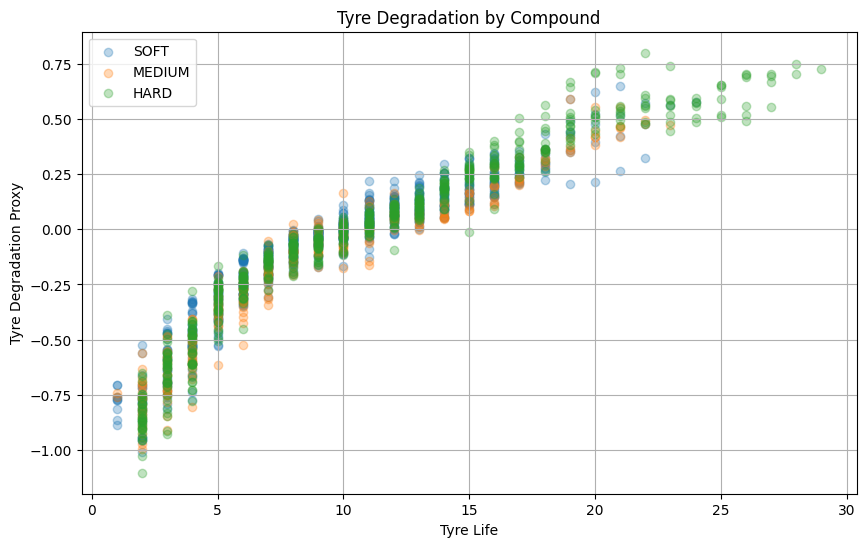

In [10]:
#külön keverékek szerinti ábrázolás
plt.figure(figsize=(10,6))

for compound in ['SOFT', 'MEDIUM', 'HARD']:

    col = f'Compound_{compound}'

    if col in plot_df.columns:

        subset = plot_df[plot_df[col] == 1]

        plt.scatter(
            subset['TyreLife'],
            subset['DegProxy'],
            alpha=0.3,
            label=compound
        )

plt.xlabel("Tyre Life")
plt.ylabel("Tyre Degradation Proxy")

plt.title("Tyre Degradation by Compound")

plt.legend()
plt.grid()

plt.show()

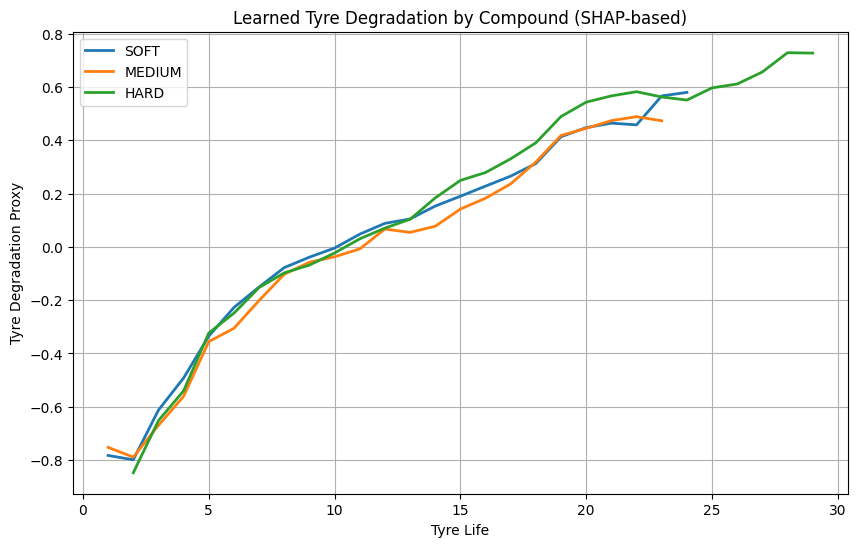

In [11]:
#simított görbével az ábra
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for compound in ['SOFT', 'MEDIUM', 'HARD']:

    col = f'Compound_{compound}'

    if col in plot_df.columns:

        subset = plot_df[plot_df[col] == 1]

        avg_deg = subset.groupby('TyreLife')['DegProxy'].mean().sort_index()

        plt.plot(
            avg_deg.index,
            avg_deg.values,
            label=compound,
            linewidth=2
        )

plt.xlabel("Tyre Life")
plt.ylabel("Tyre Degradation Proxy")
plt.title("Learned Tyre Degradation by Compound (SHAP-based)")
plt.legend()
plt.grid()
plt.show()

In [12]:
#lap time függvény:
LAPS = int(laps['LapNumber'].max())
PIT_LOSS = 25.0

print("Fixed PIT LOSS:", PIT_LOSS)

compounds = ['SOFT', 'MEDIUM', 'HARD']

#baseline_by_lap = (train_df.groupby('LapNumber')['LapTimeSeconds'].median())
baseline_table = (train_df.groupby(['Driver','LapNumber', 'Compound'])['LapTimeSeconds'].median()) #baselineba a compoundot is nézi, nem csak a tyrelifeot

def get_baseline(driver, lap, compound):

    key = (driver, lap, compound)

    if key in baseline_table.index:
        return baseline_table.loc[key]
    driver_data = train_df[
        train_df['Driver'] == driver
    ]

    if len(driver_data) > 0:
        return driver_data['LapTimeSeconds'].median()

    return train_df['LapTimeSeconds'].median()

#def get_baseline(lap):

    #if lap in baseline_by_lap.index:
        #return baseline_by_lap.loc[lap]

    #return baseline_by_lap.mean()

def lap_time(lap, tyre_life, compound, driver,team, track_temp):

    X = pd.DataFrame(
        0,
        index=[0],
        columns=base_model.feature_names_in_
    )

    # numerikus feature-ök
    if 'LapNumber' in X.columns:
        X.at[0, 'LapNumber'] = lap

    if 'TyreLife' in X.columns:
        X.at[0, 'TyreLife'] = tyre_life

    if 'TrackTemp' in X.columns:
        X.at[0, 'TrackTemp'] = track_temp

    if 'Stint' in X.columns:
        X.at[0, 'Stint'] = 1

    # compound one-hot
    compound_col = f'Compound_{compound}'

    if compound_col in X.columns:
        X.at[0, compound_col] = 1

    # driver one-hot
    driver_col = f'Driver_{driver}'

    if driver_col in X.columns:
        X.at[0, driver_col] = 1
    team_col = f'Team_{team}'

    if team_col in X.columns:
        X.at[0, team_col] = 1
    # predikció
    return base_model.predict(X)[0]

#print([c for c in X_train_tyre.columns if "Driver_" in c][:10])




Fixed PIT LOSS: 25.0


In [13]:
#DP:
SOFT = 1
MEDIUM = 2
HARD = 4

compound_to_bit = {
    "SOFT": SOFT,
    "MEDIUM": MEDIUM,
    "HARD": HARD
}

from functools import lru_cache

@lru_cache(None)
def dp(lap, tyre_life, compound, stint, driver, used_mask):
    if lap > LAPS:
        if bin(used_mask).count("1") >= 2:
            return 0
        else:
            return float('inf')
    MIN_STINT = 5
    if tyre_life < MIN_STINT:
    # csak STAY engedett
        return (get_baseline(driver,lap,compound)+ get_degradation(lap, tyre_life) + dp(lap+1, tyre_life+1, compound, stint, driver,used_mask))

    MAX_STINT = 30
    if tyre_life > MAX_STINT:
        return float('inf')

    # 1. maradsz
    stay = (get_baseline(driver,lap,compound)+ get_degradation(lap, tyre_life)+ dp(lap+1, tyre_life+1, compound, stint, driver, used_mask)) 
    # 2. box
    best_pit = float('inf')

    for new_compound in compounds:
        pit_cost = (PIT_LOSS+ get_baseline(driver,lap, new_compound)+ get_degradation(lap, 1))
        new_mask = used_mask | compound_to_bit[new_compound]
        future = dp(lap+1, 1, new_compound, stint+1, driver, new_mask)
        best_pit = min(best_pit, pit_cost + future)

    return min(stay, best_pit)

#nem csak a kintmaradás, vagy box költségét adja meg, hanem a kettő közül a kisebbet fogja választani
def policy(lap, tyre_life, compound, stint, driver, used_mask):
    stay_cost = (get_baseline(driver,lap,compound)+ get_degradation(lap, tyre_life)+ dp(lap+1, tyre_life+1, compound, stint,driver, used_mask))

    best_action = ("STAY", compound)
    best_cost = stay_cost

    for new_compound in compounds:

        pit_cost = (PIT_LOSS+ get_baseline(driver,lap, new_compound)+ get_degradation(lap, 1))
        new_mask = used_mask | compound_to_bit[new_compound]
        total = pit_cost + dp(lap+1, 1, new_compound, stint+1, driver, new_mask)

        if total < best_cost:
            best_cost = total
            best_action = ("PIT", new_compound)

    return best_action

In [14]:
#versenyszimuláció
def simulate_race(driver,start_compound='MEDIUM'):

    lap = 1
    tyre_life = 1
    compound = start_compound
    stint = 1

    used_mask = compound_to_bit[start_compound]

    total_time = 0
    strategy = []

    while lap <= LAPS:

        action, new_comp = policy(lap,tyre_life,compound,stint,driver, used_mask)

        if action == "STAY":

            lt = (get_baseline(driver,lap,compound)+ get_degradation(lap, tyre_life))
            total_time += lt
            strategy.append((lap,"STAY",compound,tyre_life))
            tyre_life += 1
            lap += 1
            used_mask = used_mask

        else:

            total_time += PIT_LOSS
            strategy.append((lap,"PIT",new_comp,tyre_life))
            compound = new_comp
            tyre_life = 1
            stint += 1
            lap += 1
            used_mask = used_mask | compound_to_bit[new_comp]

    return total_time, strategy


# VALÓS VERSENYSTRATÉGIA

START_COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
def run_full_optimization(driver): #lefuttatja a versenyt mindegyik kezdő keverékkel, és kiválasztja a legjobbat

    results = {}

    for start_c in START_COMPOUNDS:

        sim_time, sim_strategy = simulate_race(driver,start_compound=start_c)

        results[start_c] = sim_time

    best = min(results, key=results.get)

    return best, results

def real_strategy(df_driver):

    df_driver = df_driver.sort_values('LapNumber').copy()

    # ha nincs TyreLife oszlop, újraszámoljuk
    if 'TyreLife' not in df_driver.columns:

        df_driver['TyreLife'] = (
            df_driver.groupby(
                (df_driver['Compound']
                 != df_driver['Compound'].shift()).cumsum()
            ).cumcount() + 1
        )

    # boxkiállások körei
    pit_laps = df_driver[
        df_driver['PitInTime'].notna()
    ]['LapNumber'].tolist()

    # stint információk
    stints = df_driver[
        ['LapNumber', 'Compound', 'TyreLife']
    ].dropna()

    return pit_laps, stints

def real_total_time(df_driver):

    return (
        df_driver['LapTimeSeconds']
        .sum()
    )

# =========================
# 2023-AS PILÓTÁK KIÉRTÉKELÉSE
# =========================

evaluation_df = df_clean[
    df_clean['Year'] == 2023
].copy()

drivers = sorted(
    evaluation_df['Driver'].unique()
)

evaluation_results = []
all_dp_strategies = {}
all_real_strategies = {}
saved_strategies = {}
for driver in drivers:

    print("\n===================")
    print("Driver:", driver)

    driver_df = evaluation_df[
        evaluation_df['Driver'] == driver
    ].copy()

    if driver_df.empty:
        continue

    # körszám
    LAPS = int(
        driver_df['LapNumber'].max()
    )

    # cache törlés
    dp.cache_clear()

    # DP optimalizáció
    best_start, results = (
        run_full_optimization(driver)
    )

    # szimulált stratégia
    sim_time, sim_strategy = (
        simulate_race(
            driver,
            start_compound=best_start
        )
    )
    all_dp_strategies[driver] = sim_strategy

    print("DP total time:", sim_time)

    # valós stratégia
    real_pits, real_stints = (
        real_strategy(driver_df)
    )
    saved_strategies[driver] = {
    "dp_strategy": sim_strategy,
    "real_pits": real_pits,
    "real_stints": real_stints
    }

    print("Real pit laps:", real_pits)

    # valós teljes idő
    real_time = real_total_time(
        driver_df
    )

    # regret
    regret = (
        real_time
        - sim_time
    )

    # relative regret
    relative_regret = (
        regret
        / real_time
    )

    evaluation_results.append({
        'Driver': driver,
        'RealTime': real_time,
        'ModelTime': sim_time,
        'Regret': regret,
        'RelativeRegret': relative_regret
    })

    # stratégia kiírás
    print("\nSimulated strategy:")

    #for s in sim_strategy: #lassít
       # print(s)

    print("\nReal time:", real_time)
    print("Regret:", regret)

results_df = pd.DataFrame(
    evaluation_results
)

print(results_df)

#átlagolt regret:
avg_regret = (
    results_df['Regret']
    .mean()
)

avg_relative_regret = (
    results_df['RelativeRegret']
    .mean()
)

print("\nAVERAGE REGRET:", avg_regret)

print(
    "AVERAGE RELATIVE REGRET:",
    avg_relative_regret
)


Driver: ALB
DP total time: 5314.069999119205
Real pit laps: []

Simulated strategy:

Real time: 4834.918
Regret: -479.15199911920536

Driver: ALO
DP total time: 5462.805765166716
Real pit laps: []

Simulated strategy:

Real time: 4808.405999999999
Regret: -654.3997651667169

Driver: BOT
DP total time: 5294.460678482507
Real pit laps: []

Simulated strategy:

Real time: 4835.791
Regret: -458.66967848250715

Driver: DEV
DP total time: 5353.62091216431
Real pit laps: []

Simulated strategy:

Real time: 4771.072
Regret: -582.5489121643095

Driver: GAS
DP total time: 5330.7254530437
Real pit laps: []

Simulated strategy:

Real time: 4814.996
Regret: -515.7294530437002

Driver: HAM
DP total time: 5249.532212637146
Real pit laps: []

Simulated strategy:

Real time: 4819.081
Regret: -430.45121263714555

Driver: HUL
DP total time: 5368.3389121643095
Real pit laps: []

Simulated strategy:

Real time: 4744.287
Regret: -624.0519121643092

Driver: LEC
DP total time: 3689.017999625061
Real pit laps

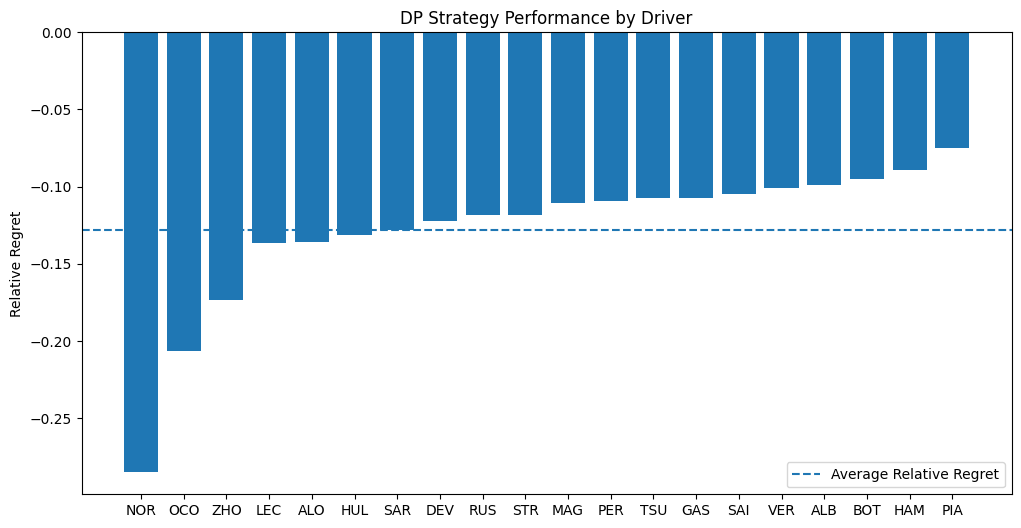

In [15]:
import matplotlib.pyplot as plt

results_df = results_df.sort_values(
    'RelativeRegret'
)

plt.figure(figsize=(12,6))

plt.bar(
    results_df['Driver'],
    results_df['RelativeRegret']
)

plt.axhline(
    avg_relative_regret,
    linestyle='--',
    label='Average Relative Regret'
)

plt.ylabel("Relative Regret")

plt.title(
    "DP Strategy Performance by Driver"
)

plt.legend()

plt.show()

In [16]:
def strategy_to_stints(strategy, total_laps):

    stints = []

    current_compound = strategy[0][2]
    start_lap = 1

    for lap, action, compound, tyre_life in strategy:

        if action == "PIT":

            stints.append(
                (
                    start_lap,
                    lap - start_lap,
                    current_compound
                )
            )

            start_lap = lap
            current_compound = compound

    stints.append(
        (
            start_lap,
            total_laps - start_lap + 1,
            current_compound
        )
    )

    return stints

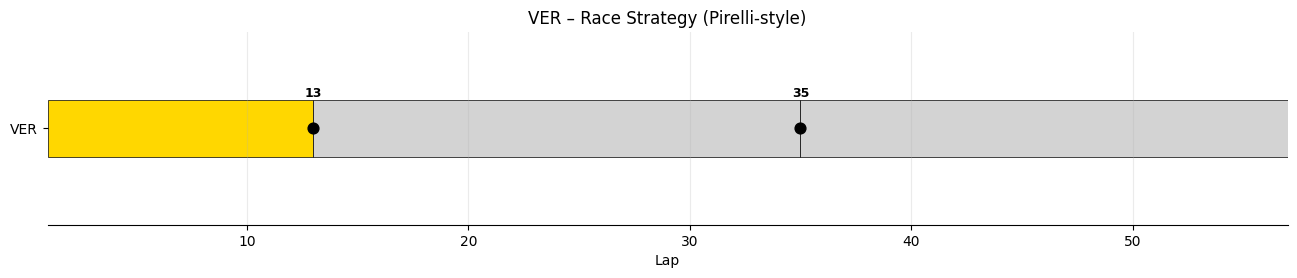

In [28]:
# DP stratégia vizualizációja 
import matplotlib.pyplot as plt

driver = "VER"

dp_strategy = saved_strategies[driver]["dp_strategy"]

total_laps = int(
    evaluation_df[evaluation_df["Driver"] == driver]["LapNumber"].max()
)

dp_stints = strategy_to_stints(dp_strategy, total_laps)

colors = {
    "SOFT": "red",
    "MEDIUM": "gold",
    "HARD": "lightgray"
}

fig, ax = plt.subplots(figsize=(16, 2.5))

pit_stops = []

# --- STINTEK ---
for i, (start, length, compound) in enumerate(dp_stints):

    end = start + length - 1

    ax.barh(
        y=0,
        width=length,
        left=start,
        height=0.35,
        color=colors[compound],
        edgecolor="black",
        linewidth=0.5
    )

    # pit stop = stint váltás
    if i > 0:
        pit_stops.append(start)

# --- PIT STOPOK ---
for lap in pit_stops:

    # fekete pont
    ax.scatter(
        lap,
        0,
        color="black",
        s=60,
        zorder=5
    )

    # körszám felirat (F1 stílus)
    ax.text(
        lap,
        0.18,
        str(lap),
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        fontweight="bold"
    )

# --- STÍLUS ---
ax.set_xlim(1, total_laps)
ax.set_ylim(-0.6, 0.6)

ax.set_yticks([0])
ax.set_yticklabels([driver])

ax.set_xlabel("Lap")

ax.set_title(f"{driver} – Race Strategy (Pirelli-style)")

ax.grid(axis="x", alpha=0.25)

# eltüntetjük a keretet (F1 dashboard feeling)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.show()